In [50]:
import dolfin as d
import h5py
import numpy as np
from smart import mesh_tools
from pathlib import Path

laminSweep = True
forceSweep = False
dSweep = False
loadFromRef = True

if laminSweep:
    # parent_folder = "/root/scratch/revision_coupled_nuc_sims/results_nanopillarsVaryLamin_2026-07-20"
    # parent_folder = "/root/scratch/revision_coupled_nuc_sims/results_nanopillars_sweepForce_2026-09-13_revision_a0_0.5"
    parent_folder = "/root/scratch/revision_coupled_nuc_sims/results_nanopillarsVaryLamin_2026-09-14"
    if dSweep:
        deltaVec = np.linspace(5.0, 75.0, 15)#np.array([2.0,4.0,6.0,8.0,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0])
        laminVec = np.ones_like(deltaVec)
        radVec = np.array([0.2])#, 0.0])
        pitchVec = np.array([3.0])#, 0.0])
    else:
        laminVec = np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5])#0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0])
        deltaVec = 65*np.ones_like(laminVec)
        radVec = np.array([0.45, 0.2, 0.0]) # 0.45, 
        pitchVec = np.array([3.5, 3.0, 0.0]) # 3.5
    # numRepeats = 10
    rupture_tests = np.zeros((len(laminVec),4))
elif forceSweep:
    # parent_folder = "/root/scratch/new_coupled_sims/results_nanopillars_pt5phiE_2026-01-30_newPhos"
    # parent_folder = "/root/scratch/new_coupled_sims/results_nanopillars_pt5Lamin_2026-01-30_newPhos_phiE"
    # parent_folder = "/root/scratch/revision_coupled_nuc_sims/results_nanopillars_pt7Lamin_2026-08-11_newPhos_phiE_New"
    parent_folder = "/root/scratch/revision_coupled_nuc_sims/results_nanopillarsVaryLaminCond_2026-09-02"
    forceVec = np.array([0.0, 400.0])#, 800.0, 800.0])
    diffVec = np.array([0.0, 0.0])#, 0.001, 0.001])
    t0Vec = np.array([1000.0, 1000.0])#, 100.0, 1000.0])
    pitchVec = np.array([0.0, 1.5, 3.0, 4.5, 6.0])
    laminVec = np.ones_like(forceVec)#np.array([0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0])
    # numRepeats = 10
    rupture_tests = np.zeros((len(laminVec),4))
    deltaVec = 65.0*np.ones_like(forceVec)

for pidx in range(len(pitchVec)):
    for Lidx in range(len(laminVec)):
        if laminSweep:
            if pitchVec[pidx] == 0:
                # folder = f"{parent_folder}/nanopillars_r0.0_p0.0_force400.0_t0100.0_lamin{laminVec[Lidx]}"
                # folder = f"{parent_folder}/nanopillars_r0.0_p0.0_force400.0_t01000.0_actin20.0"
                # folder = f"{parent_folder}/nanopillars_r0.0_p0.0_h3_force400.0"
                folder = f"{parent_folder}/nanopillars_r0.0_p0.0_force400.0_t01000.0_lamin{laminVec[Lidx]}"
            else:
                # folder = f"{parent_folder}/nanopillars_r0.5_p{pitchVec[pidx]}_force400.0_t0100.0_lamin{laminVec[Lidx]}"
                # folder = f"{parent_folder}/nanopillars_r0.2_p{pitchVec[pidx]}_force400.0_t01000.0_actin20.0"
                # folder = f"{parent_folder}/nanopillars_r0.2_p{pitchVec[pidx]}_h3_force400.0"
                folder = f"{parent_folder}/nanopillars_r{radVec[pidx]}_p{pitchVec[pidx]}_force400.0_t01000.0_lamin{laminVec[Lidx]}"
        elif forceSweep:
            if pitchVec[pidx] == 0:
                # folder = f"{parent_folder}/nanopillars_r0.0_p0.0_force{forceVec[Lidx]}_t0{t0Vec[Lidx]}_diff{diffVec[Lidx]}"
                folder = f"{parent_folder}/nanopillars_r0.0_p0.0_force{forceVec[Lidx]}_t0{t0Vec[Lidx]}_actin20.0"
            else:
                # folder = f"{parent_folder}/nanopillars_r0.2_p{pitchVec[pidx]}_force{forceVec[Lidx]}_t0{t0Vec[Lidx]}_diff{diffVec[Lidx]}"
                folder = f"{parent_folder}/nanopillars_r0.2_p{pitchVec[pidx]}_force{forceVec[Lidx]}_t0{t0Vec[Lidx]}_actin20.0"
        # folder = "/root/shared/results_testProbabilityCalc"
        tVec = np.loadtxt(f"{folder}/tvec.txt")
        loaded_mesh = mesh_tools.load_mesh(f"{folder}/mesh/nuc_mesh.h5")
        test_mesh = loaded_mesh.mesh
        mf2 = loaded_mesh.mf_facet
        mf3 = loaded_mesh.mf_cell
        NEmesh = d.create_meshview(mf2, 10)
        dx_NE = d.Measure("dx", NEmesh)
        V_NE_scalar = d.FunctionSpace(NEmesh, "P", 1)
        V_NE_vec = d.VectorFunctionSpace(NEmesh, "P", 1)
        dof_map = d.dof_to_vertex_map(V_NE_vec)[:]
        dof_map_scalar = d.dof_to_vertex_map(V_NE_scalar)[:]
        # now define DG0 space for element-wise rupture likelihoods
        V_DG0 = d.FunctionSpace(NEmesh, "DG", 0)
        DGcoords = V_DG0.tabulate_dof_coordinates()
        dof_map_DG = np.zeros_like(V_DG0.dofmap().dofs())
        for c in d.cells(NEmesh):
            cidx = c.index()
            dof_map_DG[cidx] = V_DG0.dofmap().cell_dofs(cidx)

        ulin = d.Function(V_NE_vec)
        Llin = d.Function(V_NE_scalar)
        Flin = d.Function(V_NE_scalar)
        Jlin = d.Function(V_NE_scalar)
        R0 = 4.1
        rthickness = 0.2
        z0 = min(NEmesh.coordinates()[:,2])
        Nref = d.Expression(("x[0]/(sqrt(pow(x[0],2)+pow(x[1],2)+pow(x[2]-z0,2)))",
                            "x[1]/(sqrt(pow(x[0],2)+pow(x[1],2)+pow(x[2]-z0,2)))",
                            "(x[2]-z0)/(sqrt(pow(x[0],2)+pow(x[1],2)+pow(x[2]-z0,2)))"), 
                            z0=R0+z0, degree=1)
        normals = d.project(Nref, V_NE_vec)
        # for rIdx in range(numRepeats):
        # ruptured = False
        tot_rupture_vec = np.zeros_like(tVec)
        tot_lamin_vec = np.zeros_like(tVec)
        rupture_file = d.XDMFFile(f"{folder}/rupture_cumul_d{deltaVec[Lidx]}.xdmf")
        rupture_file.parameters["flush_output"] = True
        mf_cumul = d.Function(V_DG0)
        rupture_file.write(mf_cumul, tVec[0])
        rupture_file2 = d.XDMFFile(f"{folder}/rupture_cur_d{deltaVec[Lidx]}.xdmf")
        rupture_file2.parameters["flush_output"] = True
        mf_rupture = d.Function(V_DG0)
        rupture_file2.write(mf_rupture, tVec[0])
        rupture_file3 = d.XDMFFile(f"{folder}/rupture_cumul_tot_d{deltaVec[Lidx]}.xdmf")
        rupture_file3.parameters["flush_output"] = True
        mf_cumul_tot = d.Function(V_DG0)
        rupture_file3.write(mf_cumul_tot, tVec[0])
        skipVal = 1
        foundkRupture = False
        if dSweep:
            ref_path = Path(f"{parent_folder}/rupture_tests_h2.5_p3.0_dSweep_ref.txt")
            if ref_path.is_file() and (pitchVec[pidx]==0 or loadFromRef):
                kLoad = np.loadtxt(ref_path)#f"{parent_folder}/rupture_tests_h2.5_p3.0_dSweep_ref.txt")
                krupture0 = kLoad[Lidx,2]
            else:
                if Lidx==0:
                    k_idx = 0
                    krupture0 = 1e-10
                    k_its = [krupture0]
                else:
                    k_idx = 0
                    k_its = [krupture0]
        elif not dSweep:
            krupture0 = 6.151e-18#1.23e-15#1.8e-12
        while not foundkRupture:
            totProb = 0
            for i in range(0, len(tVec)-skipVal, skipVal):#, 5, 10, 20, 50, 100, 175, 250]:
                ufile = h5py.File(f"{folder}/NE_alt_udef.h5", 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
                uarray = ufile['VisualisationVector'][f'{i}'][()]
                uarray = uarray.reshape((3*len(NEmesh.coordinates()),))
                ufile.close()
                Lfile = h5py.File(f"{folder}/LaminA.h5", 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
                Larray = Lfile['VisualisationVector'][f'{i}'][()]
                Larray = Larray.reshape((len(NEmesh.coordinates()),))
                Lfile.close()
                Ffile = h5py.File(f"{folder}/rupture_marker.h5", 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
                Farray = Ffile['VisualisationVector'][f'{i}'][()]
                Farray = Farray.reshape((len(NEmesh.coordinates()),))
                Ffile.close()

                # array matches mesh ordering; reorder according to dof mapping for Vcur
                ulin.vector().set_local(uarray[dof_map])
                ulin.vector().apply("insert")
                Llin.vector().set_local(Larray[dof_map_scalar])
                Llin.vector().apply("insert")
                Flin.vector().set_local(Farray[dof_map_scalar])
                Flin.vector().apply("insert")

                # now compute current jacobian
                Fcur = d.Identity(ulin.geometric_dimension()) + d.grad(ulin)
                areaFactorVec = d.det(Fcur) * d.dot(normals, d.inv(Fcur))
                areaFactor = d.project(d.sqrt(d.inner(areaFactorVec, areaFactorVec)), V_NE_scalar)
                areaFactor.set_allow_extrapolation(True)
                normalVec = d.project(areaFactorVec/areaFactor, V_NE_vec)
                innerScale = (R0-rthickness)/R0
                jvals = Jlin.vector()[:]
                jcoords = V_NE_scalar.tabulate_dof_coordinates()
                for idx in range(len(jcoords)):
                    jvals[idx] = (innerScale**2)*areaFactor(innerScale*jcoords[idx,0],
                                                            innerScale*jcoords[idx,1],
                                                            (z0+R0)+innerScale*(jcoords[idx,2]-z0-R0))
                Jlin.vector().set_local(jvals)
                Jlin.vector().apply("insert")

                mf_rupture_vals = mf_rupture.vector()
                kBT = 4.1
                delta = deltaVec[Lidx]
                dimerLength = 0.05
                # krupture0 = 5e-11
                Lrel = 1.0
                for c in d.cells(NEmesh):
                    xcur = c.midpoint().x()
                    ycur = c.midpoint().y()
                    zcur = c.midpoint().z()
                    Fcur = Flin(xcur,ycur,zcur)/Lrel
                    Lcur = Llin(xcur,ycur,zcur)*Lrel
                    Acur = c.volume()*Jlin(xcur,ycur,zcur)
                    rho_crosslinks = (1/np.pi) * (dimerLength*Lcur)**2
                    correctionFactor = 1 #4000/Lcur #Lcur / rho_crosslinks # pi / (Lcur * dimerLength^2)
                    NLcur = Lcur*Acur
                    krupture = krupture0*np.exp(Fcur*delta*correctionFactor/kBT)
                    dtCur = tVec[i+skipVal]-tVec[i]
                    cidx = c.index()
                    mf_rupture_vals[dof_map_DG[cidx]] = (1 - (np.exp(-krupture*dtCur))**NLcur)
                    # if np.random.uniform() < mf_rupture_vals[dof_map_DG[cidx]]:
                    #     print("Ruptured!")
                    #     ruptured = True
                    #     rupture_tests[Lidx,rIdx,0] = 1 # ruptured
                    #     rupture_tests[Lidx,rIdx,1] = tVec[i]
                    #     rupture_tests[Lidx,rIdx,2] = laminVec[Lidx]
                    #     rupture_tests[Lidx,rIdx,3] = d.assemble_mixed(Llin*Jlin*dx_NE)/d.assemble_mixed(Jlin*dx_NE)
                    #     break
                if i == 0:
                    pointwise_rupture = mf_rupture_vals
                else:
                    pointwise_rupture = 1 - (1-pointwise_rupture)*(1-mf_rupture_vals)
                mf_cumul.vector().set_local(pointwise_rupture)
                mf_cumul.vector().apply("insert")
                rupture_file.write(mf_cumul, tVec[i+1])
                mf_rupture.vector().set_local(mf_rupture_vals)
                mf_rupture.vector().apply("insert")
                rupture_file2.write(mf_rupture, tVec[i+1])

                survival = 1 - mf_rupture_vals
                tot_rupture = 1 - np.prod(survival)
                totSurvival = (1 - tot_rupture)*(1-totProb)
                totProb = 1 - totSurvival
                # if dSweep and Lidx==0 and totProb > 0.8:
                #     krupture0 *= 0.8
                #     break
                tot_rupture_vec[i+skipVal] = totProb
                mf_cumul_tot.vector().set_local(totProb*np.ones_like(pointwise_rupture))
                mf_cumul_tot.vector().apply("insert")
                rupture_file3.write(mf_cumul_tot, tVec[i+1])

                tot_lamin_vec[i] = d.assemble_mixed(Llin*Jlin*dx_NE)/d.assemble_mixed(Jlin*dx_NE) 
                np.savetxt(f"{folder}/rupture_cumul_d{deltaVec[Lidx]}.txt", tot_rupture_vec)
                np.savetxt(f"{folder}/lamin_tot_d{deltaVec[Lidx]}.txt", tot_lamin_vec)
                print(f"Done with time step {i}, overall rupture likelihood was {tot_rupture}, tot prob is {totProb}")
            tol = 0.01 # secant method tolerance
            if dSweep and pitchVec[pidx]!=0 and not loadFromRef:
                if totProb > 0.8*(1+tol) or totProb < 0.8*(1-tol):
                    if k_idx == 0:
                        if totProb > 0.8*(1+tol):
                            krupture0 *= 0.8
                        else:
                            krupture0 *= 1.25
                        prob_its = [totProb]
                    else:
                        prob_its.append(totProb)
                        estSlope = (k_its[k_idx]-k_its[k_idx-1])/(prob_its[k_idx]-prob_its[k_idx-1])
                        krupture0Test = k_its[k_idx-1] + estSlope * (0.8-prob_its[k_idx-1])
                        far_away = np.all(np.array(prob_its) > 0.8) or np.all(np.array(prob_its) < 0.8)
                        if krupture0Test < 0 or far_away:
                            if totProb > 0.8*(1+tol):
                                krupture0 *= 0.5
                            else:
                                krupture0 *= 2
                        else:
                            krupture0 = krupture0Test
                    k_its.append(krupture0)
                    k_idx += 1
                else:
                    prob_its.append(totProb)
                    estSlope = (k_its[k_idx]-k_its[k_idx-1])/(prob_its[k_idx]-prob_its[k_idx-1])
                    krupture0 = k_its[k_idx-1] + estSlope * (0.8-prob_its[k_idx-1])
                    if krupture0 < 0:
                        raise ValueError
                    foundkRupture = True
            else: # then rupture was already set
                foundkRupture = True
        if laminSweep:
            rupture_tests[Lidx,0] = totProb # cumulative likelihood
            rupture_tests[Lidx,1] = len(k_its)#tVec[i]
            if dSweep:
                rupture_tests[Lidx,2] = krupture0
            else:
                rupture_tests[Lidx,2] = laminVec[Lidx]
            rupture_tests[Lidx,3] = d.assemble_mixed(Llin*Jlin*dx_NE)/d.assemble_mixed(Jlin*dx_NE)
        elif forceSweep:
            rupture_tests[Lidx,0] = totProb # cumulative likelihood
            rupture_tests[Lidx,1] = tVec[i]
            rupture_tests[Lidx,2] = forceVec[Lidx]
            rupture_tests[Lidx,3] = t0Vec[Lidx]

        if dSweep:
            np.savetxt(f"{parent_folder}/rupture_tests_h2.5_p{pitchVec[pidx]}_dSweep.txt", rupture_tests)
        else:
            np.savetxt(f"{parent_folder}/rupture_tests_h2.5_p{pitchVec[pidx]}_d{deltaVec[Lidx]}_redo.txt", rupture_tests)


/tmp/ipykernel_421086/111948978.py:80: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dof_map_DG[cidx] = V_DG0.dofmap().cell_dofs(cidx)


Building point search tree to accelerate distance queries.
Computed bounding box tree with 7423 nodes for 3712 points.
Done with time step 0, overall rupture likelihood was 1.8555001979336794e-10, tot prob is 1.8555001979336794e-10
Done with time step 1, overall rupture likelihood was 2.0734869377037057e-10, tot prob is 3.928987135637385e-10
Done with time step 2, overall rupture likelihood was 2.204020299600984e-10, tot prob is 6.133007435238369e-10
Done with time step 3, overall rupture likelihood was 2.435025514557765e-10, tot prob is 8.568032949796134e-10
Done with time step 4, overall rupture likelihood was 2.6207069847572484e-10, tot prob is 1.1188739934553382e-09
Done with time step 5, overall rupture likelihood was 2.9093605302676906e-10, tot prob is 1.4098100464821073e-09
Done with time step 6, overall rupture likelihood was 3.2154012785667874e-10, tot prob is 1.731350174338786e-09
Done with time step 7, overall rupture likelihood was 3.4776803659042343e-10, tot prob is 2.0791

ROOT -2026-09-22 04:15:49,619 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-22 04:15:49,621 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-22 04:15:49,623 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-22 04:15:49,629 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-22 04:15:49,630 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-22 04:15:49,631 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-22 04:15:49,640 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-22 04:15:49,641 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-22 04:15:49,641 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-22 04:15:49,644 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-22 04:15:49,655 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-22 04:15:49,658 fontTools

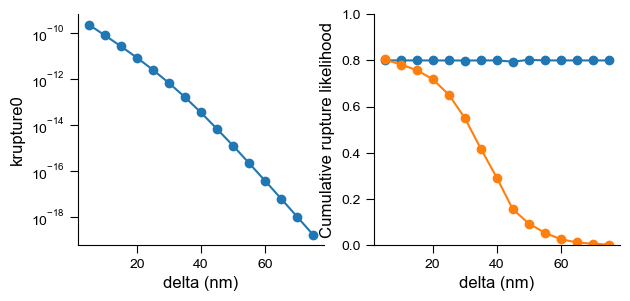

In [30]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(f"/root/shared/gitrepos/smart-mechanotransduction/plotting/smart_plots.mplstyle")
matplotlib.rcParams.update({'figure.figsize': (7,3)})
parent_folder = "/root/scratch/revision_coupled_nuc_sims/results_nanopillarsVaryLamin_2026-09-14"
p3RuptureData = np.loadtxt(f"{parent_folder}/rupture_tests_h2.5_p3.0_dSweep.txt")
p0RuptureData = np.loadtxt(f"{parent_folder}/rupture_tests_h2.5_p0.0_dSweep.txt")
deltaVals = np.linspace(5.0, 75.0, 15)
plt.subplot(1,2,1)
plt.semilogy(deltaVals, p3RuptureData[:,2], '-o')
plt.xlabel('delta (nm)')
plt.ylabel('krupture0')
plt.subplot(1,2,2)
plt.plot(deltaVals, p3RuptureData[:,0], '-o')
plt.plot(deltaVals, p0RuptureData[:,0], '-o')
plt.ylim([0, 1])
plt.xlabel('delta (nm)')
plt.ylabel('Cumulative rupture likelihood')
plt.savefig("ruptureParams.pdf", format="pdf")

ROOT -2026-09-22 04:25:01,029 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-22 04:25:01,030 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-22 04:25:01,030 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-22 04:25:01,032 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-22 04:25:01,033 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-22 04:25:01,034 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-22 04:25:01,035 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-22 04:25:01,036 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-22 04:25:01,037 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-22 04:25:01,039 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-22 04:25:01,043 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-22 04:25:01,045 fontTools

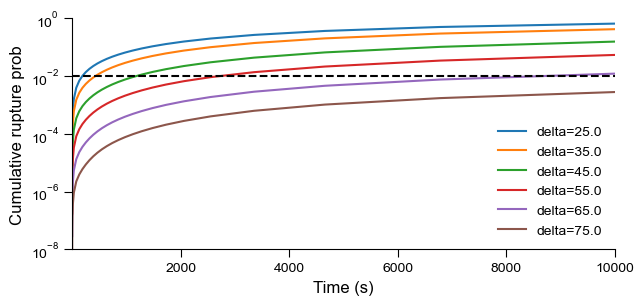

In [48]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(f"/root/shared/gitrepos/smart-mechanotransduction/plotting/smart_plots.mplstyle")
matplotlib.rcParams.update({'figure.figsize': (7,3)})
parent_folder = "/root/scratch/revision_coupled_nuc_sims/results_nanopillarsVaryLamin_2026-09-14"
dPlot = [25.0, 35.0, 45.0, 55.0, 65.0, 75.0]
for i in range(len(dPlot)):
    ruptureData = np.loadtxt(f"{parent_folder}/nanopillars_r0.0_p0.0_force400.0_t01000.0_lamin1.0/rupture_cumul_d{dPlot[i]}.txt")
    tvec = np.loadtxt(f"{parent_folder}/nanopillars_r0.0_p0.0_force400.0_t01000.0_lamin1.0/tvec.txt")
    skipVal = 10
    plt.semilogy(tvec[skipVal::10], ruptureData[skipVal::10], label=f"delta={dPlot[i]}")

plt.legend()
plt.semilogy([0.1,10000], [0.01,0.01],'--',color='k')
plt.ylim([1e-8,1])
plt.xlim([0.1,10000])
plt.ylabel("Cumulative rupture prob")
plt.xlabel("Time (s)")
plt.savefig("ruptureDyn.pdf", format="pdf")

ROOT -2026-09-17 08:16:24,656 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-17 08:16:24,656 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-17 08:16:24,657 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-17 08:16:24,659 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-17 08:16:24,660 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-17 08:16:24,661 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-17 08:16:24,662 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-17 08:16:24,663 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-17 08:16:24,663 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-17 08:16:24,664 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-17 08:16:24,666 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-17 08:16:24,669 fontTools

1.0
1.0
0.9922257288002987
0.3431030998255934
0.10887739246353811
0.06580549298341576
0.05800480823109122
0.059371394866199134
0.06555471934018753
0.07349784550785388
0.08352822984685171


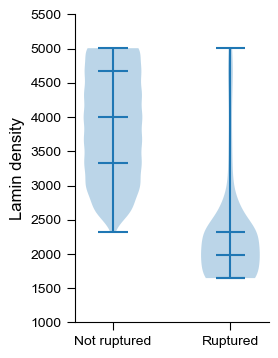

In [26]:
import dolfin as d
import h5py
import numpy as np
from smart import mesh_tools
import matplotlib
from matplotlib import pyplot as plt
plt.style.use(f"/root/shared/gitrepos/smart-mechanotransduction/plotting/smart_plots.mplstyle")
matplotlib.rcParams.update({'figure.figsize': (2.5,4)})

parent_folder = "/root/scratch/revision_coupled_nuc_sims/results_nanopillarsVaryLamin_2026-09-14"
laminVec = np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5])#np.array([0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0])
# numRepeats = 10
ruptured_lamins = []
nonruptured_lamins = []
for Lidx in range(len(laminVec)):
    folder = f"{parent_folder}/nanopillars_r0.45_p3.5_force400.0_t01000.0_lamin{laminVec[Lidx]}"
    # folder = "/root/shared/results_testProbabilityCalc"
    tVec = np.loadtxt(f"{folder}/tvec.txt")
    tList = [3600]
    tot_rupture_vec = np.loadtxt(f"{folder}/rupture_cumul_d50.0.txt")
    tot_lamin_vec = np.loadtxt(f"{folder}/lamin_tot_d50.0.txt")
    numRepeats = 200
    for i in range(len(tList)):#, 5, 10, 20, 50, 100, 175, 250]:
        idx = int(np.round(np.argmin(np.abs(tList[i]-tVec))/skipVal) * skipVal)
        curProb = tot_rupture_vec[idx+skipVal]
        print(curProb)
        for j in range(numRepeats):
            if np.random.uniform() < curProb:
                ruptured_lamins.append(tot_lamin_vec[idx])
            else:
                nonruptured_lamins.append(tot_lamin_vec[idx])
# plt.plot(np.random.uniform(size=(len(nonruptured_lamins),1))*0.2 + 0.9, 
#          nonruptured_lamins, 'x')
# plt.plot(0, np.mean(nonruptured_lamins), 'o')
# plt.plot(np.random.uniform(size=(len(ruptured_lamins),1))*0.2 + 1.9, 
#          ruptured_lamins, 'x')
# plt.plot(1, np.mean(ruptured_lamins), 'o')
plt.violinplot((nonruptured_lamins, ruptured_lamins,),
               showmedians=True, quantiles=([0.25,0.75],[0.25,0.75]))
plt.ylim([1000, 5500])
plt.xticks([1, 2], ['Not ruptured', 'Ruptured'])
plt.ylabel('Lamin density')
from scipy import stats
stats.ttest_ind(nonruptured_lamins, ruptured_lamins)
plt.savefig("ruptureLikelihood.pdf", format="pdf")

In [ ]:
import dolfin as d
import h5py
import numpy as np
from smart import mesh_tools
import matplotlib
from matplotlib import pyplot as plt
plt.style.use(f"/root/shared/gitrepos/smart-mechanotransduction/plotting/smart_plots.mplstyle")
matplotlib.rcParams.update({'figure.figsize': (3,4)})

# parent_folder = "/root/scratch/new_coupled_sims/results_nanopillars_pt5phiE_2026-01-30_newPhos"
# parent_folder = "/root/scratch/new_coupled_sims/results_nanopillars_pt5Lamin_2026-01-30_newPhos_phiE"
parent_folder = "/root/scratch/revision_coupled_nuc_sims/results_nanopillars_pt7Lamin_2026-08-11_newPhos_phiE_New"
forceVec = np.array([0.0, 400.0, 400.0, 800.0, 800.0])
diffVec = np.array([0.001, 0.001, 0.001, 0.001, 0.001])
t0Vec = np.array([100.0, 100.0, 1000.0, 100.0, 1000.0])
pitchVec = np.array([0.0, 2.0, 3.0, 4.0, 5.0, 6.0])
cumul_rupture = np.zeros((len(pitchVec),len(forceVec)))
for pidx in range(len(pitchVec)):
    for Lidx in [1,2]:#range(len(forceVec)):
        if pitchVec[pidx] == 0:
            folder = f"{parent_folder}/nanopillars_r0.0_p0.0_force{forceVec[Lidx]}_t0{t0Vec[Lidx]}_diff{diffVec[Lidx]}"
        else:
            folder = f"{parent_folder}/nanopillars_r0.2_p{pitchVec[pidx]}_force{forceVec[Lidx]}_t0{t0Vec[Lidx]}_diff{diffVec[Lidx]}"
        # folder = "/root/shared/results_testProbabilityCalc"
        tVec = np.loadtxt(f"{folder}/tvec.txt")
        tVal = 600
        tot_rupture_vec = np.loadtxt(f"{folder}/rupture_cumul_d34.0.txt")
        cumul_rupture[pidx][Lidx] = np.interp(tVal, tVec[0::skipVal], tot_rupture_vec[0::skipVal])

    
np_means = {
    'Fast': cumul_rupture[:,1],
    'Slow': cumul_rupture[:,2],
}
width = 0.4
x = np.arange(len(pitchVec))
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(5,4))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('Cumulative rupture likelihood')
ax.set_xticks(x + width/2, pitchVec)#[::2])
ax.set_xlabel('Pitch (µm)')
ax.legend()#loc='upper right')
plt.ylim([0,1])
# plt.savefig("forcePerLamin_lowLamin.pdf", format="pdf")
# plt.savefig("ruptureLikelihood_pitchDep_L50.pdf", format="pdf")